# 13. AI-Assisted Method Selection

Method selection is not a keyword matching problem. It is a design problem.

A causal method is appropriate only when the estimand, assignment mechanism, data structure, timing, assumptions, and diagnostics line up. A regression model is not a causal design by itself. A causal forest is not a magic fix for confounding. Difference-in-differences is not appropriate merely because the data has dates. Instrumental variables are not appropriate merely because a variable predicts treatment.

This notebook builds an AI-assisted workflow for method selection. The deterministic layer encodes method requirements and rejection reasons. The LLM layer reviews project cards and produces a structured method recommendation. The audit layer checks whether the model preserved the causal design logic.

## Learning Goals

By the end of this notebook you should be able to:

1. Treat method selection as an estimand-and-design problem rather than a model-choice problem.
2. Map common causal methods to required data structures, assumptions, and diagnostic checks.
3. Build project cards that contain enough information for method screening.
4. Use deterministic rules to produce method shortlists and rejection reasons.
5. Show why naive keyword-based method selection is brittle.
6. Ask local LLMs for structured method recommendations while forbidding unsupported leaps.
7. Audit AI recommendations for design mismatch, missing assumptions, and overconfident method choices.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal work needs deterministic checks, structured outputs, model comparison, repair logic, and human review.

Method-selection notebooks are especially brittle because LLMs often know the names of methods but may not respect their assumptions. A model may recommend difference-in-differences without credible pre-trends, IV without an exclusion restriction, or causal forests when the real problem is nonrandom treatment assignment. We will keep that brittleness visible and score it directly.

## 1. Setup

The deterministic sections use project cards, method catalogs, rule-based screening, and simple visualizations. The optional AI sections use the shared local LLM utilities from previous Course 05 notebooks.

In [1]:
import importlib.util
import json
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 2000
TEMPERATURE = 0.0
SEED = 213
MODEL_COMPARISON_CASE_LIMIT = 3

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 160)

In [3]:
def has_package(module_name):
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'pandas', 'available': has_package('pandas'), 'used_for': 'method catalog and screening tables'},
        {'package': 'sklearn', 'available': has_package('sklearn'), 'used_for': 'naive keyword baseline'},
        {'package': 'seaborn', 'available': has_package('seaborn'), 'used_for': 'method shortlist visualization'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured AI method recommendation schema'},
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM method review'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
package_status

CUDA available to this kernel: True


,package,available,used_for
0,pandas,True,method catalog and screening tables
1,sklearn,True,naive keyword baseline
2,seaborn,True,method shortlist visualization
3,pydantic,True,structured AI method recommendation schema
4,transformers,True,optional local LLM method review
5,torch,True,GPU inference if live LLMs are enabled


## 2. Method Selection Is Design Selection

A method recommendation should answer four questions before it names a model:

1. **What is the estimand?** Total effect, direct effect, ATT, CATE, policy value, local effect, or rollout effect?
2. **What generated treatment variation?** Randomization, threshold rule, staggered rollout, instrument, observed targeting, logged policy, or one treated unit?
3. **What data structure is available?** Cross-section, panel, time series, clustered units, pre/post data, running variable, propensities, or rich covariates?
4. **Which assumptions are plausible and testable?** Exchangeability, overlap, parallel trends, exclusion, monotonicity, continuity, no interference, stable logging policy.

Only after those answers should we choose an estimator.

In [4]:
method_selection_principles = pd.DataFrame(
    [
        {
            'principle': 'Start from the estimand',
            'bad habit': 'Pick a fashionable estimator first.',
            'better habit': 'Define the causal quantity and target population before choosing a method.',
        },
        {
            'principle': 'Use the assignment mechanism',
            'bad habit': 'Treat every observational dataset as a regression problem.',
            'better habit': 'Exploit randomization, thresholds, instruments, rollouts, or logged policies when they actually exist.',
        },
        {
            'principle': 'Reject methods explicitly',
            'bad habit': 'Give only one recommended method.',
            'better habit': 'List viable methods and methods rejected with reasons.',
        },
        {
            'principle': 'Separate identification from estimation',
            'bad habit': 'Assume a flexible model solves identification.',
            'better habit': 'State the assumptions first; then choose an estimator appropriate for those assumptions.',
        },
        {
            'principle': 'Treat AI as reviewer, not authority',
            'bad habit': 'Accept a model recommendation because it sounds technical.',
            'better habit': 'Audit whether the recommendation matches the project card and method requirements.',
        },
    ]
)
method_selection_principles

,principle,bad habit,better habit
0,Start from the estimand,Pick a fashionable estimator first.,Define the causal quantity and target population before choosing a method.
1,Use the assignment mechanism,Treat every observational dataset as a regression problem.,"Exploit randomization, thresholds, instruments, rollouts, or logged policies when they actually exist."
2,Reject methods explicitly,Give only one recommended method.,List viable methods and methods rejected with reasons.
3,Separate identification from estimation,Assume a flexible model solves identification.,State the assumptions first; then choose an estimator appropriate for those assumptions.
4,"Treat AI as reviewer, not authority",Accept a model recommendation because it sounds technical.,Audit whether the recommendation matches the project card and method requirements.


### Discussion

Method selection often fails through overfitting to vocabulary. If the project says “rollout,” a model may jump to difference-in-differences. If the project says “score,” it may jump to regression discontinuity. If the project says “recommendation system,” it may jump to off-policy evaluation. Those jumps are valid only when the design conditions are present.

## 3. Method Catalog

We begin with a compact catalog. This is not an encyclopedia. It is a screening tool: what must be true before a method belongs on the shortlist?

In [5]:
method_catalog = pd.DataFrame(
    [
        {
            'method': 'Randomized experiment / A/B test',
            'primary_use': 'Estimate treatment effect when treatment was randomized.',
            'requires': 'Known random assignment, treatment/control groups, outcome measured after assignment.',
            'key_assumptions': 'Randomization implemented correctly; no major interference; consistent outcome measurement.',
            'diagnostics': 'Sample ratio mismatch, covariate balance, attrition, guardrails, interference checks.',
            'red_flags': 'Treatment chosen by users or managers; post-treatment sample restriction; broken logging.',
        },
        {
            'method': 'Regression / covariate adjustment',
            'primary_use': 'Adjust for measured pre-treatment confounders in observational data.',
            'requires': 'Rich pre-treatment confounders, clear treatment timing, outcome after treatment.',
            'key_assumptions': 'Conditional exchangeability, overlap, no bad controls, correct enough functional form.',
            'diagnostics': 'Balance, overlap, residual confounding review, sensitivity analysis.',
            'red_flags': 'Important confounders missing; controls measured after treatment; weak overlap.',
        },
        {
            'method': 'Matching / weighting / IPW',
            'primary_use': 'Create comparable treated and control groups under measured confounding.',
            'requires': 'Pre-treatment covariates, positivity, enough comparable units.',
            'key_assumptions': 'Conditional exchangeability, positivity, stable treatment definition.',
            'diagnostics': 'Propensity overlap, standardized mean differences, weight distribution, effective sample size.',
            'red_flags': 'Extreme propensities; unstable weights; important unmeasured confounding.',
        },
        {
            'method': 'Doubly robust / AIPW',
            'primary_use': 'Combine outcome modeling and propensity modeling for observational adjustment.',
            'requires': 'Pre-treatment covariates, overlap, outcome and treatment nuisance models.',
            'key_assumptions': 'Exchangeability and positivity; at least one nuisance model well specified for robustness claims.',
            'diagnostics': 'Overlap, nuisance model validation, influence diagnostics, sensitivity analysis.',
            'red_flags': 'No credible confounder set; poor overlap; post-treatment features in nuisance models.',
        },
        {
            'method': 'Double ML / orthogonal ML',
            'primary_use': 'Estimate low-dimensional treatment effects with flexible nuisance models.',
            'requires': 'Rich covariates, sufficient sample size, cross-fitting, clear treatment/outcome timing.',
            'key_assumptions': 'Exchangeability, overlap, nuisance rates adequate, no bad controls.',
            'diagnostics': 'Cross-fitting, nuisance performance, overlap, sensitivity to learners.',
            'red_flags': 'Small sample; unmeasured confounding; using ML to hide design weakness.',
        },
        {
            'method': 'Causal forests / CATE modeling',
            'primary_use': 'Explore heterogeneous treatment effects after identification strategy is credible.',
            'requires': 'Credible treatment variation, rich pre-treatment features, enough sample for heterogeneity.',
            'key_assumptions': 'Identification assumptions for treatment effect plus honest heterogeneity estimation.',
            'diagnostics': 'Policy risk, calibration, subgroup stability, overlap by subgroup.',
            'red_flags': 'Using heterogeneity model before identifying average effect; post-treatment features.',
        },
        {
            'method': 'Difference-in-differences / event study',
            'primary_use': 'Estimate effects from treated/control units observed before and after rollout.',
            'requires': 'Panel or repeated outcomes, untreated comparison units, treatment timing, credible pre-trends.',
            'key_assumptions': 'Parallel trends or justified conditional parallel trends; no anticipation; stable composition.',
            'diagnostics': 'Pre-trends, event-study leads/lags, placebo outcomes, treatment timing heterogeneity.',
            'red_flags': 'No pre-period; no comparison group; differential shocks; staggered rollout without modern estimator.',
        },
        {
            'method': 'Synthetic control',
            'primary_use': 'Estimate effect for one or few treated aggregate units using donor units.',
            'requires': 'Aggregate panel, one/few treated units, many donor units, long pre-period.',
            'key_assumptions': 'Weighted donor combination approximates treated counterfactual; no donor contamination.',
            'diagnostics': 'Pre-period fit, placebo treated units, donor weights, sensitivity to donor pool.',
            'red_flags': 'Many treated units with little pre-period; treated unit unlike all donors; spillovers to donors.',
        },
        {
            'method': 'Regression discontinuity',
            'primary_use': 'Estimate local effect at a known assignment threshold.',
            'requires': 'Running variable, cutoff rule, units near cutoff, no manipulation around threshold.',
            'key_assumptions': 'Continuity of potential outcomes at cutoff; no precise manipulation; local estimand accepted.',
            'diagnostics': 'Density test, covariate continuity, bandwidth sensitivity, local polynomial specification.',
            'red_flags': 'Score is only predictive not determinative; managers override cutoff; few units near threshold.',
        },
        {
            'method': 'Instrumental variables',
            'primary_use': 'Estimate local effect using exogenous variation in treatment uptake.',
            'requires': 'Relevant instrument that shifts treatment but affects outcome only through treatment.',
            'key_assumptions': 'Relevance, exclusion restriction, independence, monotonicity for LATE.',
            'diagnostics': 'First stage, exclusion argument, balance by instrument, monotonicity/domain review.',
            'red_flags': 'Instrument directly affects outcome; weak first stage; unclear compliance population.',
        },
        {
            'method': 'Off-policy evaluation',
            'primary_use': 'Evaluate a new policy using logged bandit/recommender decisions.',
            'requires': 'Logged actions, rewards, propensities or known logging policy, target policy definition.',
            'key_assumptions': 'Unconfounded logged action conditional on context, overlap between logging and target policies, correct rewards.',
            'diagnostics': 'Propensity support, effective sample size, IPS/DR agreement, policy overlap.',
            'red_flags': 'No propensities; deterministic logging with no overlap; reward measured after policy-dependent censoring.',
        },
    ]
)
method_catalog

,method,primary_use,requires,key_assumptions,diagnostics,red_flags
0,Randomized experiment / A/B test,Estimate treatment effect when treatment was randomized.,"Known random assignment, treatment/control groups, outcome measured after assignment.",Randomization implemented correctly; no major interference; consistent outcome measurement.,"Sample ratio mismatch, covariate balance, attrition, guardrails, interference checks.",Treatment chosen by users or managers; post-treatment sample restriction; broken logging.
1,Regression / covariate adjustment,Adjust for measured pre-treatment confounders in observational data.,"Rich pre-treatment confounders, clear treatment timing, outcome after treatment.","Conditional exchangeability, overlap, no bad controls, correct enough functional form.","Balance, overlap, residual confounding review, sensitivity analysis.",Important confounders missing; controls measured after treatment; weak overlap.
2,Matching / weighting / IPW,Create comparable treated and control groups under measured confounding.,"Pre-treatment covariates, positivity, enough comparable units.","Conditional exchangeability, positivity, stable treatment definition.","Propensity overlap, standardized mean differences, weight distribution, effective sample size.",Extreme propensities; unstable weights; important unmeasured confounding.
3,Doubly robust / AIPW,Combine outcome modeling and propensity modeling for observational adjustment.,"Pre-treatment covariates, overlap, outcome and treatment nuisance models.",Exchangeability and positivity; at least one nuisance model well specified for robustness claims.,"Overlap, nuisance model validation, influence diagnostics, sensitivity analysis.",No credible confounder set; poor overlap; post-treatment features in nuisance models.
4,Double ML / orthogonal ML,Estimate low-dimensional treatment effects with flexible nuisance models.,"Rich covariates, sufficient sample size, cross-fitting, clear treatment/outcome timing.","Exchangeability, overlap, nuisance rates adequate, no bad controls.","Cross-fitting, nuisance performance, overlap, sensitivity to learners.",Small sample; unmeasured confounding; using ML to hide design weakness.
5,Causal forests / CATE modeling,Explore heterogeneous treatment effects after identification strategy is credible.,"Credible treatment variation, rich pre-treatment features, enough sample for heterogeneity.",Identification assumptions for treatment effect plus honest heterogeneity estimation.,"Policy risk, calibration, subgroup stability, overlap by subgroup.",Using heterogeneity model before identifying average effect; post-treatment features.
6,Difference-in-differences / event study,Estimate effects from treated/control units observed before and after rollout.,"Panel or repeated outcomes, untreated comparison units, treatment timing, credible pre-trends.",Parallel trends or justified conditional parallel trends; no anticipation; stable composition.,"Pre-trends, event-study leads/lags, placebo outcomes, treatment timing heterogeneity.",No pre-period; no comparison group; differential shocks; staggered rollout without modern estimator.
7,Synthetic control,Estimate effect for one or few treated aggregate units using donor units.,"Aggregate panel, one/few treated units, many donor units, long pre-period.",Weighted donor combination approximates treated counterfactual; no donor contamination.,"Pre-period fit, placebo treated units, donor weights, sensitivity to donor pool.",Many treated units with little pre-period; treated unit unlike all donors; spillovers to donors.
8,Regression discontinuity,Estimate local effect at a known assignment threshold.,"Running variable, cutoff rule, units near cutoff, no manipulation around threshold.",Continuity of potential outcomes at cutoff; no precise manipulation; local estimand accepted.,"Density test, covariate continuity, bandwidth sensitivity, local polynomial specification.",Score is only predictive not determinative; ma

### Discussion

The catalog should make one thing obvious: every method has a rejection path. A professional recommendation should include methods not chosen and why. That is especially important when AI is involved, because a fluent one-method answer can hide many unsupported assumptions.

## 4. Project Cards

A project card is the input to method selection. It should contain the business question, estimand, treatment assignment story, data structure, timing, candidate assumptions, and missing information.

In [6]:
project_cards = [
    {
        'case_id': 'checkout_banner_experiment',
        'business_question': 'Did a checkout banner increase completed purchases without increasing refunds?',
        'estimand': 'ATE of banner assignment on 14-day purchase completion among eligible checkout sessions.',
        'assignment_mechanism': 'User-level randomized experiment with known treatment allocation.',
        'data_structure': 'Individual sessions with randomization logs, pre-treatment covariates, outcomes, and guardrails.',
        'timing': 'Treatment assigned at checkout entry; outcomes measured after assignment.',
        'available_signals': ['randomized_assignment', 'unit_level_data', 'post_treatment_outcome', 'guardrail_outcome', 'balance_covariates'],
        'known_risks': ['sample_ratio_mismatch_possible', 'interference_low_but_possible', 'refund_guardrail_needed'],
        'missing_information': ['attrition by arm', 'bot filtering rules'],
        'expected_primary_method': 'Randomized experiment / A/B test',
    },
    {
        'case_id': 'retention_outreach_observational',
        'business_question': 'Did retention outreach improve renewal among at-risk customers?',
        'estimand': 'ATE or ATT of outreach assignment on 90-day renewal for eligible at-risk accounts.',
        'assignment_mechanism': 'Customer-success managers targeted accounts using risk score, value, and judgment.',
        'data_structure': 'Account-level observational data with rich pre-treatment covariates and post-treatment outcomes.',
        'timing': 'Treatment timing known; risk and account covariates measured before outreach.',
        'available_signals': ['observational_targeting', 'rich_pre_treatment_covariates', 'overlap_must_be_checked', 'unit_level_data'],
        'known_risks': ['unmeasured_manager_judgment', 'poor_overlap_possible', 'post_treatment_engagement_variables'],
        'missing_information': ['manager notes', 'overlap diagnostics', 'sensitivity analysis plan'],
        'expected_primary_method': 'Doubly robust / AIPW',
    },
    {
        'case_id': 'regional_policy_rollout',
        'business_question': 'Did the new delivery-fee policy reduce low-margin orders?',
        'estimand': 'Average effect of policy adoption on weekly low-margin order share for treated regions.',
        'assignment_mechanism': 'Policy rolled out to some regions at known dates by operations leadership.',
        'data_structure': 'Region-week panel with treated and untreated regions, many pre-periods, and weekly outcomes.',
        'timing': 'Region adoption dates known; outcome measured weekly before and after rollout.',
        'available_signals': ['panel_data', 'staggered_rollout', 'treated_and_control_units', 'pre_periods', 'post_periods'],
        'known_risks': ['parallel_trends_not_guaranteed', 'differential_regional_shocks', 'staggered_timing_bias'],
        'missing_information': ['event-study pre-trends', 'regional shock controls', 'spillover assessment'],
        'expected_primary_method': 'Difference-in-differences / event study',
    },
    {
        'case_id': 'credit_limit_cutoff',
        'business_question': 'Did automatic credit-limit review increase six-month card usage?',
        'estimand': 'Local effect of review eligibility at the risk-score cutoff.',
        'assignment_mechanism': 'Accounts with risk score below 620 were automatically routed to review.',
        'data_structure': 'Account-level data with running score, cutoff, treatment, and outcomes near threshold.',
        'timing': 'Score computed before routing; usage measured after review window.',
        'available_signals': ['running_variable', 'known_cutoff', 'units_near_cutoff', 'local_estimand'],
        'known_risks': ['manual_overrides_possible', 'score_manipulation_possible', 'local_effect_only'],
        'missing_information': ['density test', 'override frequency', 'bandwidth sensitivity'],
        'expected_primary_method': 'Regression discontinuity',
    },
    {
        'case_id': 'warehouse_robotics_single_site',
        'business_question': 'Did installing robotics at the Phoenix warehouse reduce fulfillment cost?',
        'estimand': 'Effect of robotics installation on weekly fulfillment cost for the Phoenix warehouse.',
        'assignment_mechanism': 'One warehouse received robotics based on capital planning; other warehouses are possible donors.',
        'data_structure': 'Warehouse-week aggregate panel with one treated site, donor sites, and long pre-period.',
        'timing': 'Treatment date known; weekly outcomes observed before and after installation.',
        'available_signals': ['single_treated_unit', 'aggregate_panel', 'donor_pool', 'long_pre_period'],
        'known_risks': ['donor_contamination_possible', 'treated_site_unique', 'pre_period_fit_required'],
        'missing_information': ['pre-period fit', 'donor eligibility', 'placebo tests'],
        'expected_primary_method': 'Synthetic control',
    },
    {
        'case_id': 'physician_preference_instrument',
        'business_question': 'Did prescribing the new medication reduce readmission?',
        'estimand': 'Local effect of treatment among patients whose treatment is shifted by physician preference.',
        'assignment_mechanism': 'Patients are more likely to receive medication from physicians with high historical preference.',
        'data_structure': 'Patient-level observational data with physician preference measure, treatment, covariates, and outcomes.',
        'timing': 'Preference measure based on prior prescribing history; treatment before outcome.',
        'available_signals': ['candidate_instrument', 'treatment_uptake', 'unit_level_data', 'covariates'],
        'known_risks': ['exclusion_restriction_questionable', 'physician_quality_confounding', 'weak_first_stage_possible'],
        'missing_information': ['first-stage strength', 'exclusion argument', 'balance by instrument'],
        'expected_primary_method': 'Instrumental variables',
    },
    {
        'case_id': 'logged_recommender_policy',
        'business_question': 'Would a new recommendation policy increase long-run engagement?',
        'estimand': 'Expected reward under target policy relative to logged policy for eligible recommendation contexts.',
        'assignment_mechanism': 'Historical recommender logged actions using a stochastic policy with recorded propensities.',
        'data_structure': 'Context-action-reward logs with propensities and target policy scores.',
        'timing': 'Context observed before action; reward observed after recommendation.',
        'available_signals': ['logged_actions', 'logged_propensities', 'target_policy', 'context_features', 'reward'],
        'known_risks': ['policy_overlap_must_be_checked', 'reward_censoring_possible', 'long_run_feedback_not_captured'],
        'missing_information': ['effective sample size', 'overlap by action', 'reward definition stability'],
        'expected_primary_method': 'Off-policy evaluation',
    },
]

project_cards_df = pd.DataFrame(project_cards)
project_cards_df[['case_id', 'assignment_mechanism', 'data_structure', 'expected_primary_method']]

,case_id,assignment_mechanism,data_structure,expected_primary_method
0,checkout_banner_experiment,User-level randomized experiment with known treatment allocation.,"Individual sessions with randomization logs, pre-treatment covariates, outcomes, and guardrails.",Randomized experiment / A/B test
1,retention_outreach_observational,"Customer-success managers targeted accounts using risk score, value, and judgment.",Account-level observational data with rich pre-treatment covariates and post-treatment outcomes.,Doubly robust / AIPW
2,regional_policy_rollout,Policy rolled out to some regions at known dates by operations leadership.,"Region-week panel with treated and untreated regions, many pre-periods, and weekly outcomes.",Difference-in-differences / event study
3,credit_limit_cutoff,Accounts with risk score below 620 were automatically routed to review.,"Account-level data with running score, cutoff, treatment, and outcomes near threshold.",Regression discontinuity
4,warehouse_robotics_single_site,One warehouse received robotics based on capital planning; other warehouses are possible donors.,"Warehouse-week aggregate panel with one treated site, donor sites, and long pre-period.",Synthetic control
5,physician_preference_instrument,Patients are more likely to receive medication from physicians with high historical preference.,"Patient-level observational data with physician preference measure, treatment, covariates, and outcomes.",Instrumental variables
6,logged_recommender_policy,Historical recommender logged actions using a stochastic policy with recorded propensities.,Context-action-reward logs with propensities and target policy scores.,Off-policy evaluation


### Discussion

These cards are deliberately short, but they include enough structure to avoid pure keyword matching. The same word can appear in multiple designs. What matters is the combination of assignment mechanism, data structure, and assumptions.

## 5. Deterministic Screening Rules

A rule-based screener is not a replacement for judgment. It is a guardrail. It forces the method recommendation to cite design signals and rejection reasons.

In [7]:
METHOD_REQUIREMENTS = {
    'Randomized experiment / A/B test': {
        'required': {'randomized_assignment', 'unit_level_data', 'post_treatment_outcome'},
        'supporting': {'guardrail_outcome', 'balance_covariates'},
        'rejection_if_missing': 'No known random assignment or outcome after assignment.',
    },
    'Regression / covariate adjustment': {
        'required': {'unit_level_data', 'rich_pre_treatment_covariates'},
        'supporting': {'observational_targeting', 'overlap_must_be_checked'},
        'rejection_if_missing': 'Needs rich pre-treatment covariates and known timing.',
    },
    'Matching / weighting / IPW': {
        'required': {'unit_level_data', 'rich_pre_treatment_covariates', 'overlap_must_be_checked'},
        'supporting': {'observational_targeting'},
        'rejection_if_missing': 'Needs measured confounders plus overlap diagnostics.',
    },
    'Doubly robust / AIPW': {
        'required': {'unit_level_data', 'rich_pre_treatment_covariates', 'overlap_must_be_checked'},
        'supporting': {'observational_targeting'},
        'rejection_if_missing': 'Needs measured confounders, overlap, and nuisance modeling plan.',
    },
    'Double ML / orthogonal ML': {
        'required': {'unit_level_data', 'rich_pre_treatment_covariates', 'overlap_must_be_checked'},
        'supporting': {'observational_targeting'},
        'rejection_if_missing': 'Needs enough sample and rich covariates; does not solve unmeasured confounding.',
    },
    'Causal forests / CATE modeling': {
        'required': {'unit_level_data', 'rich_pre_treatment_covariates'},
        'supporting': {'overlap_must_be_checked'},
        'rejection_if_missing': 'Needs credible identification before heterogeneity modeling.',
    },
    'Difference-in-differences / event study': {
        'required': {'panel_data', 'treated_and_control_units', 'pre_periods', 'post_periods'},
        'supporting': {'staggered_rollout'},
        'rejection_if_missing': 'Needs treated/control units with pre and post outcomes.',
    },
    'Synthetic control': {
        'required': {'single_treated_unit', 'aggregate_panel', 'donor_pool', 'long_pre_period'},
        'supporting': set(),
        'rejection_if_missing': 'Needs one/few treated aggregate units, donor pool, and long pre-period.',
    },
    'Regression discontinuity': {
        'required': {'running_variable', 'known_cutoff', 'units_near_cutoff'},
        'supporting': {'local_estimand'},
        'rejection_if_missing': 'Needs a known cutoff rule and enough units near the threshold.',
    },
    'Instrumental variables': {
        'required': {'candidate_instrument', 'treatment_uptake', 'unit_level_data'},
        'supporting': {'covariates'},
        'rejection_if_missing': 'Needs a relevant instrument and a credible exclusion argument.',
    },
    'Off-policy evaluation': {
        'required': {'logged_actions', 'logged_propensities', 'target_policy', 'context_features', 'reward'},
        'supporting': set(),
        'rejection_if_missing': 'Needs logged actions, propensities, target policy, contexts, and rewards.',
    },
}


def screen_methods(project_card):
    signals = set(project_card['available_signals'])
    rows = []
    for method, req in METHOD_REQUIREMENTS.items():
        required = req['required']
        supporting = req['supporting']
        missing_required = sorted(required - signals)
        matched_required = sorted(required & signals)
        matched_supporting = sorted(supporting & signals)
        required_score = len(matched_required) / len(required) if required else 1.0
        supporting_score = len(matched_supporting) / len(supporting) if supporting else 0.0
        score = 0.85 * required_score + 0.15 * supporting_score
        viable = len(missing_required) == 0
        rows.append(
            {
                'case_id': project_card['case_id'],
                'method': method,
                'score': score,
                'viable_by_rules': viable,
                'matched_required': matched_required,
                'missing_required': missing_required,
                'matched_supporting': matched_supporting,
                'screening_note': 'viable shortlist candidate' if viable else req['rejection_if_missing'],
            }
        )
    return pd.DataFrame(rows).sort_values(['viable_by_rules', 'score'], ascending=[False, False])

screened_all = pd.concat([screen_methods(card) for card in project_cards], ignore_index=True)
screened_all.head(15)

,case_id,method,score,viable_by_rules,matched_required,missing_required,matched_supporting,screening_note
0,checkout_banner_experiment,Randomized experiment / A/B test,1.000000,True,"[post_treatment_outcome, randomized_assignment, unit_level_data]",[],"[balance_covariates, guardrail_outcome]",viable shortlist candidate
1,checkout_banner_experiment,Regression / covariate adjustment,0.425000,False,[unit_level_data],[rich_pre_treatment_covariates],[],Needs rich pre-treatment covariates and known timing.
2,checkout_banner_experiment,Causal forests / CATE modeling,0.425000,False,[unit_level_data],[rich_pre_treatment_covariates],[],Needs credible identification before heterogeneity modeling.
3,checkout_banner_experiment,Matching / weighting / IPW,0.283333,False,[unit_level_data],"[overlap_must_be_checked, rich_pre_treatment_covariates]",[],Needs measured confounders plus overlap diagnostics.
4,checkout_banner_experiment,Doubly robust / AIPW,0.283333,False,[unit_level_data],"[overlap_must_be_checked, rich_pre_treatment_covariates]",[],"Needs measured confounders, overlap, and nuisance modeling plan."
5,checkout_banner_experiment,Double ML / orthogonal ML,0.283333,False,[unit_level_data],"[overlap_must_be_checked, rich_pre_treatment_covariates]",[],Needs enough sample and rich covariates; does not solve unmeasured confounding.
6,checkout_banner_experiment,Instrumental variables,0.283333,False,[unit_level_data],"[candidate_instrument, treatment_uptake]",[],Needs a relevant instrument and a credible exclusion argument.
7,checkout_banner_experiment,Difference-in-differences / event study,0.000000,False,[],"[panel_data, post_periods, pre_periods, treated_and_control_units]",[],Needs treated/control units with pre and post outcomes.
8,checkout_banner_experiment,Synthetic control,0.000000,False,[],"[aggregate_panel, donor_pool, long_pre_period, single_treated_unit]",[],"Needs one/few treated aggregate units, donor pool, and long pre-period."
9,checkout_banner_experiment,Regression discontinuity,0.000000,False,[],"[known_cutoff, running_variable, units_near_cutoff]",[],Needs a known cutoff rule and enough units near the threshold.


In [8]:
shortlist = (
    screened_all
    .query('viable_by_rules')
    .groupby('case_id', as_index=False)
    .agg(shortlisted_methods=('method', list))
    .merge(project_cards_df[['case_id', 'expected_primary_method']], on='case_id')
)
shortlist

,case_id,shortlisted_methods,expected_primary_method
0,checkout_banner_experiment,[Randomized experiment / A/B test],Randomized experiment / A/B test
1,credit_limit_cutoff,[Regression discontinuity],Regression discontinuity
2,logged_recommender_policy,[Off-policy evaluation],Off-policy evaluation
3,physician_preference_instrument,[Instrumental variables],Instrumental variables
4,regional_policy_rollout,[Difference-in-differences / event study],Difference-in-differences / event study
5,retention_outreach_observational,"[Regression / covariate adjustment, Matching / weighting / IPW, Doubly robust / AIPW, Double ML / orthogonal ML, Causal forests / CATE modeling]",Doubly robust / AIPW
6,warehouse_robotics_single_site,[Synthetic control],Synthetic control


### Discussion

The screener often returns more than one viable method. That is good. Method selection is usually a shortlist plus a diagnostic plan, not a single magic answer.

For example, an observational retention project may shortlist regression adjustment, weighting, AIPW, Double ML, and CATE modeling. The primary recommendation should depend on the estimand, sample size, overlap, nuisance-model needs, and whether heterogeneity is a primary goal or a secondary analysis.

## 6. Visualize the Method Shortlist

A heatmap makes it easy to see which methods are plausible for which project cards.

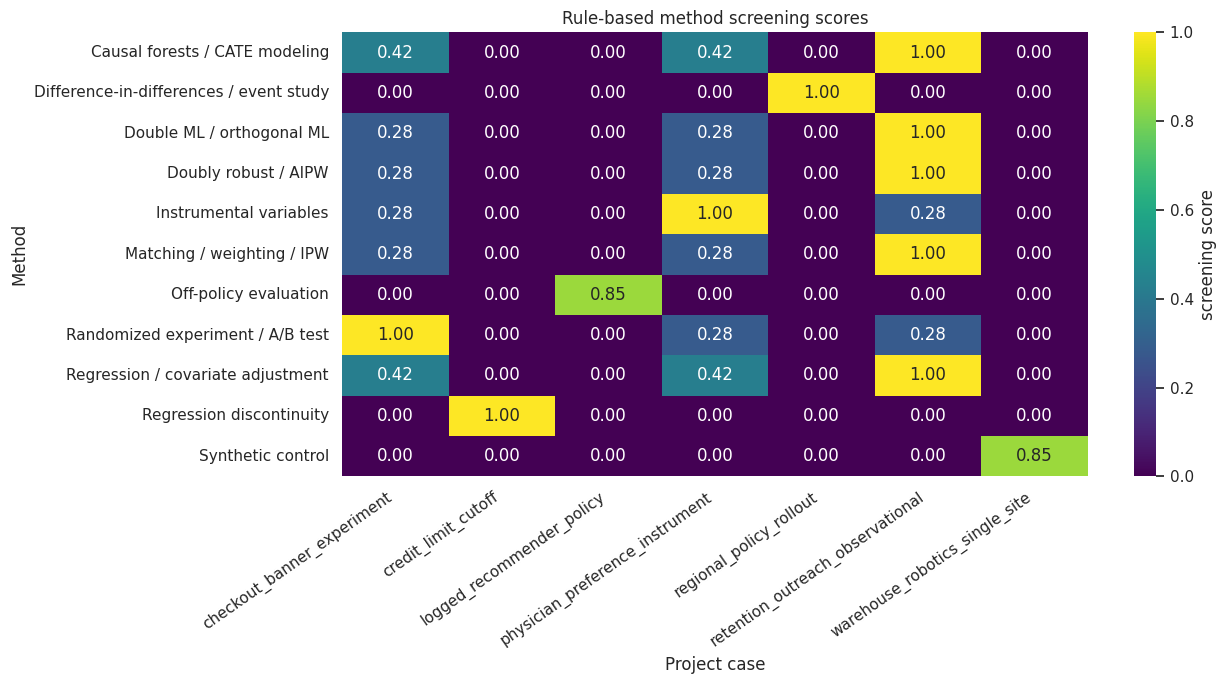

In [9]:
heatmap_data = screened_all.pivot(index='method', columns='case_id', values='score')
fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'screening score'}, ax=ax)
ax.set_title('Rule-based method screening scores')
ax.set_xlabel('Project case')
ax.set_ylabel('Method')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### Discussion

This heatmap is not a final decision. It is a triage tool. It reveals which methods deserve deeper diagnostic work and which methods should be rejected early.

## 7. Why Keyword Matching Fails

To make the point concrete, we build a naive keyword selector. It compares each project card to method descriptions using TF-IDF similarity.

This is intentionally weak. It demonstrates a common AI failure mode: selecting a method because the language sounds similar rather than because the design conditions are satisfied.

In [10]:
def project_text(card):
    return ' '.join(
        [
            card['business_question'],
            card['estimand'],
            card['assignment_mechanism'],
            card['data_structure'],
            card['timing'],
            ' '.join(card['available_signals']),
            ' '.join(card['known_risks']),
        ]
    )

method_catalog['method_text'] = method_catalog[['primary_use', 'requires', 'key_assumptions', 'diagnostics', 'red_flags']].agg(' '.join, axis=1)
project_texts = [project_text(card) for card in project_cards]
method_texts = method_catalog['method_text'].tolist()
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(project_texts + method_texts)
similarity = cosine_similarity(X[:len(project_texts)], X[len(project_texts):])

keyword_rows = []
for i, card in enumerate(project_cards):
    order = np.argsort(similarity[i])[::-1]
    for rank, method_idx in enumerate(order[:3], start=1):
        keyword_rows.append(
            {
                'case_id': card['case_id'],
                'rank': rank,
                'keyword_method': method_catalog.iloc[method_idx]['method'],
                'similarity': similarity[i, method_idx],
                'expected_primary_method': card['expected_primary_method'],
            }
        )
keyword_results = pd.DataFrame(keyword_rows)
keyword_results

,case_id,rank,keyword_method,similarity,expected_primary_method
0,checkout_banner_experiment,1,Randomized experiment / A/B test,0.176034,Randomized experiment / A/B test
1,checkout_banner_experiment,2,Regression / covariate adjustment,0.080115,Randomized experiment / A/B test
2,checkout_banner_experiment,3,Causal forests / CATE modeling,0.057605,Randomized experiment / A/B test
3,retention_outreach_observational,1,Causal forests / CATE modeling,0.132027,Doubly robust / AIPW
4,retention_outreach_observational,2,Regression / covariate adjustment,0.119740,Doubly robust / AIPW
5,retention_outreach_observational,3,Randomized experiment / A/B test,0.115762,Doubly robust / AIPW
6,regional_policy_rollout,1,Off-policy evaluation,0.144332,Difference-in-differences / event study
7,regional_policy_rollout,2,Synthetic control,0.086610,Difference-in-differences / event study
8,regional_policy_rollout,3,Difference-in-differences / event study,0.080543,Difference-in-differences / event study
9,credit_limit_cutoff,1,Regression discontinuity,0.274030,Regression discontinuity


In [11]:
keyword_top1 = keyword_results.query('rank == 1').copy()
keyword_top1['top1_matches_expected'] = keyword_top1['keyword_method'].eq(keyword_top1['expected_primary_method'])
keyword_top1[['case_id', 'keyword_method', 'expected_primary_method', 'top1_matches_expected', 'similarity']]

,case_id,keyword_method,expected_primary_method,top1_matches_expected,similarity
0,checkout_banner_experiment,Randomized experiment / A/B test,Randomized experiment / A/B test,True,0.176034
3,retention_outreach_observational,Causal forests / CATE modeling,Doubly robust / AIPW,False,0.132027
6,regional_policy_rollout,Off-policy evaluation,Difference-in-differences / event study,False,0.144332
9,credit_limit_cutoff,Regression discontinuity,Regression discontinuity,True,0.274030
12,warehouse_robotics_single_site,Synthetic control,Synthetic control,True,0.179732
15,physician_preference_instrument,Regression / covariate adjustment,Instrumental variables,False,0.096916
18,logged_recommender_policy,Off-policy evaluation,Off-policy evaluation,True,0.473870


### Discussion

The keyword baseline can be right for the wrong reason or wrong for an understandable reason. That is the danger. Similar language is not the same as design validity.

An LLM can behave like a much more fluent keyword matcher if we do not force it to cite assignment mechanism, data structure, assumptions, and rejection reasons.

## 8. Build a Method-Selection Bundle

The bundle given to the LLM includes the project card, deterministic screening results, and the method catalog. The prompt asks for a recommendation with rejection reasons and diagnostics.

In [12]:
def dataframe_records(df, max_rows=30):
    return json.loads(df.head(max_rows).to_json(orient='records', date_format='iso'))


def make_selection_bundle(card):
    case_screen = screen_methods(card)
    return {
        'project_card': card,
        'deterministic_screening': dataframe_records(case_screen, max_rows=20),
        'method_catalog': dataframe_records(method_catalog.drop(columns=['method_text']), max_rows=20),
        'instructions': [
            'Recommend methods only when design requirements are met or clearly state what must be verified.',
            'Include rejected methods with reasons.',
            'Do not recommend randomized experiments unless random assignment exists.',
            'Do not recommend DiD merely because time appears; require treated/control units and credible pre-trends.',
            'Do not recommend IV merely because a variable predicts treatment; require exclusion and relevance arguments.',
            'Do not recommend RDD merely because a score exists; require a cutoff rule and local estimand.',
        ],
    }

example_card = project_cards[1]
example_bundle = make_selection_bundle(example_card)
print(json.dumps(example_bundle, indent=2)[:5000])

{
  "project_card": {
    "case_id": "retention_outreach_observational",
    "business_question": "Did retention outreach improve renewal among at-risk customers?",
    "estimand": "ATE or ATT of outreach assignment on 90-day renewal for eligible at-risk accounts.",
    "assignment_mechanism": "Customer-success managers targeted accounts using risk score, value, and judgment.",
    "data_structure": "Account-level observational data with rich pre-treatment covariates and post-treatment outcomes.",
    "timing": "Treatment timing known; risk and account covariates measured before outreach.",
    "available_signals": [
      "observational_targeting",
      "rich_pre_treatment_covariates",
      "overlap_must_be_checked",
      "unit_level_data"
    ],
    "known_risks": [
      "unmeasured_manager_judgment",
      "poor_overlap_possible",
      "post_treatment_engagement_variables"
    ],
    "missing_information": [
      "manager notes",
      "overlap diagnostics",
      "sensitivity

### Discussion

The LLM is now reviewing a structured bundle rather than inventing a method from a vague business question. This is the professional pattern: use the model to reason over evidence that we control.

## 9. Shared Local LLM Runtime

We reuse the shared local LLM utilities from `notebooks/_shared` so the model comparison stays consistent with earlier notebooks.

In [13]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    clean_generated_text,
    clear_loaded_model_cache,
    get_device,
    local_chat as _shared_local_chat,
)
from notebooks._shared.structured_outputs import parse_pydantic_output

DEVICE = get_device()


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )

print(f'Local LLM device: {DEVICE}')

Local LLM device: cuda


## 10. Structured AI Method Recommendation

We ask for a structured recommendation. The schema forces the model to separate the primary recommendation, alternatives, rejected methods, assumptions, diagnostics, and missing information.

In [14]:
class MethodSelectionReview(BaseModel):
    project_summary: str = Field(description='Brief summary of the causal design problem.')
    estimand: str = Field(description='The target causal estimand.')
    recommended_primary_method: str = Field(description='The best primary method or method family.')
    primary_method_rationale: list[str] = Field(description='Reasons the method fits the assignment mechanism and data structure.')
    viable_alternatives: list[str] = Field(description='Other plausible methods and when they may be useful.')
    rejected_methods: list[str] = Field(description='Methods rejected with explicit reasons.')
    required_assumptions: list[str] = Field(description='Assumptions needed for the primary method.')
    required_diagnostics: list[str] = Field(description='Diagnostics or validation checks before estimation.')
    missing_information: list[str] = Field(description='Information that must be collected or verified.')
    misuse_warnings: list[str] = Field(description='Warnings about tempting but invalid method choices.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the recommendation given the project card.')

REVIEW_SCALAR_FIELDS = ['project_summary', 'estimand', 'recommended_primary_method', 'confidence']
REVIEW_LIST_FIELDS = [
    'primary_method_rationale',
    'viable_alternatives',
    'rejected_methods',
    'required_assumptions',
    'required_diagnostics',
    'missing_information',
    'misuse_warnings',
]
REVIEW_ALIASES = {
    'primary_method': 'recommended_primary_method',
    'recommendation': 'recommended_primary_method',
    'rationale': 'primary_method_rationale',
    'alternatives': 'viable_alternatives',
    'rejections': 'rejected_methods',
    'assumptions': 'required_assumptions',
    'diagnostics': 'required_diagnostics',
    'missing_info': 'missing_information',
    'warnings': 'misuse_warnings',
}


def parse_method_selection_review(raw_output):
    result = parse_pydantic_output(
        raw_output,
        MethodSelectionReview,
        scalar_fields=REVIEW_SCALAR_FIELDS,
        list_fields=REVIEW_LIST_FIELDS,
        field_aliases=REVIEW_ALIASES,
        defaults={'confidence': 'medium'},
    )
    return result.parsed, result.json_text, result.notes

In [15]:
SYSTEM_REVIEW_MESSAGE = (
    'You are a careful causal inference method-selection reviewer.\n'
    'Rules:\n'
    '- Use only the provided method-selection bundle.\n'
    '- Return valid JSON only. No markdown. No preamble.\n'
    '- Recommend a method only when the assignment mechanism and data structure support it.\n'
    '- Include rejected methods with concrete design reasons.\n'
    '- Do not confuse prediction, flexible modeling, or method popularity with identification.\n'
    '- Do not recommend randomization, IV, RDD, DiD, synthetic control, or OPE unless their design requirements appear in the bundle.\n'
    '- Mention missing diagnostics rather than pretending assumptions are already satisfied.\n'
)


def build_review_prompt(bundle):
    schema_hint = {
        'project_summary': 'string',
        'estimand': 'string',
        'recommended_primary_method': 'string',
        'primary_method_rationale': ['string'],
        'viable_alternatives': ['string'],
        'rejected_methods': ['string'],
        'required_assumptions': ['string'],
        'required_diagnostics': ['string'],
        'missing_information': ['string'],
        'misuse_warnings': ['string'],
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce a MethodSelectionReview JSON object using this schema:
        {json.dumps(schema_hint, indent=2)}

        Method-selection bundle:
        {json.dumps(bundle, indent=2)}
        '''
    ).strip()

review_prompt = build_review_prompt(example_bundle)
print(review_prompt[:3000])

Produce a MethodSelectionReview JSON object using this schema:
        {
  "project_summary": "string",
  "estimand": "string",
  "recommended_primary_method": "string",
  "primary_method_rationale": [
    "string"
  ],
  "viable_alternatives": [
    "string"
  ],
  "rejected_methods": [
    "string"
  ],
  "required_assumptions": [
    "string"
  ],
  "required_diagnostics": [
    "string"
  ],
  "missing_information": [
    "string"
  ],
  "misuse_warnings": [
    "string"
  ],
  "confidence": "low | medium | high"
}

        Method-selection bundle:
        {
  "project_card": {
    "case_id": "retention_outreach_observational",
    "business_question": "Did retention outreach improve renewal among at-risk customers?",
    "estimand": "ATE or ATT of outreach assignment on 90-day renewal for eligible at-risk accounts.",
    "assignment_mechanism": "Customer-success managers targeted accounts using risk score, value, and judgment.",
    "data_structure": "Account-level observational d

## 11. Run One Local Model

We start with the retention outreach observational card. The expected answer should favor an observational adjustment family such as AIPW or related doubly robust adjustment, while clearly warning about unmeasured manager judgment and overlap.

In [16]:
if RUN_LIVE_LOCAL_LLM:
    raw_review_output = local_chat(
        review_prompt,
        system_message=SYSTEM_REVIEW_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
    )
    display(Markdown('### Raw model output'))
    display(Markdown(f'```json\n{clean_generated_text(raw_review_output)}\n```'))
else:
    raw_review_output = ''
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM call in the rendered notebook.')

### Raw model output

```json
{
 "project_summary": "The project aims to determine if retention outreach improved renewal among at-risk customers using observational data with rich pre-treatment covariates and post-treatment outcomes.",
 "estimand": "ATE or ATT of outreach assignment on 90-day renewal for eligible at-risk accounts.",
 "recommended_primary_method": "Doubly robust / AIPW",
 "primary_method_rationale": [
 "Combines the strengths of both outcome and propensity modeling, providing robustness against model misspecification.",
 "Supports rich pre-treatment covariates and allows for flexible modeling of both the outcome and propensity scores.",
 "Can handle complex assignment mechanisms and provides valid estimates even if some parts of the model are misspecified."
 ],
 "viable_alternatives": [
 "Regression / covariate adjustment",
 "Matching / weighting / IPW"
 ],
 "rejected_methods": [
 "Randomized experiment / A/B test",
 "Instrumental variables",
 "Difference-in-differences / event study",
 "Synthetic control",
 "Regression discontinuity",
 "Off-policy evaluation"
 ],
 "required_assumptions": [
 "Exchangeability and positivity",
 "Correct specification of nuisance models (outcome and propensity)"
 ],
 "required_diagnostics": [
 "Overlap check",
 "Nuisance model validation",
 "Influence diagnostics",
 "Sensitivity analysis"
 ],
 "missing_information": [
 "Manager notes",
 "Overlap diagnostics",
 "Sensitivity analysis plan"
 ],
 "misuse_warnings": [
 "Ensure that the treatment assignment is not influenced by user or manager discretion.",
 "Verify that the outcome is measured consistently across all units."
 ],
 "confidence": "medium"
}
```

In [17]:
if raw_review_output:
    try:
        method_review, method_review_json, review_parser_notes = parse_method_selection_review(raw_review_output)
        single_model_parse_error = ''
        display(Markdown('### Parsed method-selection review'))
        display(Markdown(f'```json\n{method_review.model_dump_json(indent=2)}\n```'))
        print('Parser notes:', review_parser_notes)
    except Exception as error:
        method_review = None
        method_review_json = ''
        review_parser_notes = []
        single_model_parse_error = clean_generated_text(repr(error))
        print('The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.')
        print(single_model_parse_error[:1200])
else:
    method_review = None
    method_review_json = ''
    review_parser_notes = []
    single_model_parse_error = ''

### Parsed method-selection review

```json
{
  "project_summary": "The project aims to determine if retention outreach improved renewal among at-risk customers using observational data with rich pre-treatment covariates and post-treatment outcomes.",
  "estimand": "ATE or ATT of outreach assignment on 90-day renewal for eligible at-risk accounts.",
  "recommended_primary_method": "Doubly robust / AIPW",
  "primary_method_rationale": [
    "Combines the strengths of both outcome and propensity modeling, providing robustness against model misspecification.",
    "Supports rich pre-treatment covariates and allows for flexible modeling of both the outcome and propensity scores.",
    "Can handle complex assignment mechanisms and provides valid estimates even if some parts of the model are misspecified."
  ],
  "viable_alternatives": [
    "Regression / covariate adjustment",
    "Matching / weighting / IPW"
  ],
  "rejected_methods": [
    "Randomized experiment / A/B test",
    "Instrumental variables",
    "Difference-in-differences / event study",
    "Synthetic control",
    "Regression discontinuity",
    "Off-policy evaluation"
  ],
  "required_assumptions": [
    "Exchangeability and positivity",
    "Correct specification of nuisance models (outcome and propensity)"
  ],
  "required_diagnostics": [
    "Overlap check",
    "Nuisance model validation",
    "Influence diagnostics",
    "Sensitivity analysis"
  ],
  "missing_information": [
    "Manager notes",
    "Overlap diagnostics",
    "Sensitivity analysis plan"
  ],
  "misuse_warnings": [
    "Ensure that the treatment assignment is not influenced by user or manager discretion.",
    "Verify that the outcome is measured consistently across all units."
  ],
  "confidence": "medium"
}
```

Parser notes: []


## 12. Audit the AI Recommendation

The audit checks whether the model recommended a method compatible with the expected design and avoided methods whose requirements are absent.

In [18]:
METHOD_FAMILIES = {
    'Randomized experiment / A/B test': ['randomized', 'experiment', 'a/b', 'ab test'],
    'Doubly robust / AIPW': ['doubly robust', 'aipw', 'augmented inverse probability', 'dr'],
    'Regression / covariate adjustment': ['regression', 'covariate adjustment', 'adjustment'],
    'Matching / weighting / IPW': ['matching', 'weighting', 'ipw', 'inverse probability'],
    'Double ML / orthogonal ML': ['double ml', 'orthogonal', 'dml'],
    'Difference-in-differences / event study': ['difference-in-differences', 'difference in differences', 'did', 'event study'],
    'Synthetic control': ['synthetic control'],
    'Regression discontinuity': ['regression discontinuity', 'rdd', 'cutoff'],
    'Instrumental variables': ['instrumental', 'iv', 'instrument'],
    'Off-policy evaluation': ['off-policy', 'ope', 'logged policy', 'ips'],
}


def review_text(review):
    if review is None:
        return ''
    return clean_generated_text(json.dumps(review.model_dump(), sort_keys=True)).lower()


def contains_any(text, terms):
    return any(term.lower() in text for term in terms)


def method_mentioned(text, method_name):
    return contains_any(text, METHOD_FAMILIES.get(method_name, [method_name]))


def recommended_method_matches(review, expected_method):
    if review is None:
        return False
    rec = clean_generated_text(review.recommended_primary_method).lower()
    if expected_method == 'Doubly robust / AIPW':
        return method_mentioned(rec, 'Doubly robust / AIPW') or method_mentioned(rec, 'Regression / covariate adjustment') or method_mentioned(rec, 'Matching / weighting / IPW')
    return method_mentioned(rec, expected_method)


def unsupported_design_methods_for_card(card):
    signals = set(card['available_signals'])
    unsupported = []
    for method, req in METHOD_REQUIREMENTS.items():
        if req['required'] - signals:
            unsupported.append(method)
    return unsupported


def score_method_review(review, card):
    text = review_text(review)
    expected = card['expected_primary_method']
    unsupported = unsupported_design_methods_for_card(card)
    rec_text = clean_generated_text(review.recommended_primary_method).lower() if review is not None else ''
    unsupported_in_primary = [method for method in unsupported if method_mentioned(rec_text, method)]
    checks = {
        'states estimand': contains_any(text, [card['estimand'].split(' of ')[0], card['estimand'].split(' on ')[0]]) or 'estimand' in text,
        'primary method compatible with expected design': recommended_method_matches(review, expected),
        'rationale cites assignment or data structure': contains_any(text, ['assignment', 'data structure', 'randomized', 'observational', 'panel', 'cutoff', 'logged', 'donor', 'instrument']),
        'lists required assumptions': len(review.required_assumptions) >= 2 if review is not None else False,
        'lists diagnostics': len(review.required_diagnostics) >= 2 if review is not None else False,
        'includes missing information': len(review.missing_information) >= 1 if review is not None else False,
        'includes rejected methods': len(review.rejected_methods) >= 2 if review is not None else False,
        'primary recommendation avoids unsupported method family': len(unsupported_in_primary) == 0,
        'warns about misuse or limitations': len(review.misuse_warnings) >= 1 if review is not None else False,
        'does not claim method proves causality automatically': not contains_any(text, ['guarantees causality', 'proves causality', 'automatically identifies']),
    }
    audit = pd.DataFrame([{'check': key, 'passed': bool(value)} for key, value in checks.items()])
    audit['credit'] = audit['passed'].astype(int)
    return audit, int(audit['credit'].sum()), len(audit), unsupported_in_primary

if method_review is not None:
    single_audit, single_score, single_max_score, unsupported_primary = score_method_review(method_review, example_card)
    print(f'Score: {single_score}/{single_max_score}')
    print('Unsupported methods in primary recommendation:', unsupported_primary)
    display(single_audit)
else:
    print('No method review to audit because live model execution was skipped or parsing failed.')

Score: 10/10
Unsupported methods in primary recommendation: []


,check,passed,credit
0,states estimand,True,1
1,primary method compatible with expected design,True,1
2,rationale cites assignment or data structure,True,1
3,lists required assumptions,True,1
4,lists diagnostics,True,1
5,includes missing information,True,1
6,includes rejected methods,True,1
7,primary recommendation avoids unsupported method family,True,1
8,warns about misuse or limitations,True,1
9,does not claim method proves causality automatically,True,1


### Discussion

The audit is intentionally strict about the primary recommendation. It is fine for a model to discuss rejected methods. It is not fine for the model to recommend IV, RDD, DiD, or synthetic control when the required design signals are absent.

## 13. Optional All-Model Comparison

Now we compare local models on multiple project cards. This is more demanding than a single example because a good model must switch methods as the design changes.

The exact ranking can change across reruns and environments. That is expected. The durable lesson is not which model wins today. The durable lesson is that method-selection assistance must be evaluated case by case, with explicit design checks.

In [19]:
METHOD_SELECTION_EVAL_CASES = [
    {'case_id': card['case_id'], 'card': card, 'bundle': make_selection_bundle(card)}
    for card in project_cards
]

SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_review_score', 'failure_types'
]
CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'expected_method', 'recommended_primary_method', 'status',
    'schema_valid', 'repair_used', 'repair_stage', 'error_type', 'review_score', 'max_review_score',
    'review_score_share', 'unsupported_primary_methods', 'error', 'raw_output_preview'
]

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required MethodSelectionReview JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def empty_method_review():
    return MethodSelectionReview(
        project_summary='',
        estimand='',
        recommended_primary_method='',
        primary_method_rationale=[],
        viable_alternatives=[],
        rejected_methods=[],
        required_assumptions=[],
        required_diagnostics=[],
        missing_information=[],
        misuse_warnings=[],
        confidence='low',
    )


def parse_or_repair_review(raw_output, model_id):
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_method_selection_review(raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': notes,
            'repair_used': bool(notes),
            'repair_stage': 'parser' if notes else 'none',
            'repaired_raw_output': '',
        }
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:7000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, notes = parse_method_selection_review(repaired_raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def run_single_model_selection_case(label, model_id, role, case):
    prompt = build_review_prompt(case['bundle'])
    raw_output = ''
    max_score = score_method_review(empty_method_review(), case['card'])[2]
    try:
        raw_output = local_chat(
            prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed_result = parse_or_repair_review(raw_output, model_id)
        audit, score, max_score, unsupported_primary = score_method_review(parsed_result['parsed'], case['card'])
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'expected_method': case['card']['expected_primary_method'],
            'recommended_primary_method': parsed_result['parsed'].recommended_primary_method,
            'status': 'ok',
            'schema_valid': True,
            'repair_used': parsed_result['repair_used'],
            'repair_stage': parsed_result['repair_stage'],
            'error_type': '',
            'review_score': score,
            'max_review_score': max_score,
            'review_score_share': score / max_score if max_score else 0.0,
            'unsupported_primary_methods': unsupported_primary,
            'error': '',
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }
    except Exception as error:
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'expected_method': case['card']['expected_primary_method'],
            'recommended_primary_method': '',
            'status': 'failed',
            'schema_valid': False,
            'repair_used': False,
            'repair_stage': 'failed',
            'error_type': classify_structured_output_failure(error),
            'review_score': 0,
            'max_review_score': max_score,
            'review_score_share': 0.0,
            'unsupported_primary_methods': [],
            'error': clean_generated_text(repr(error))[:900],
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }


def summarize_model_results(case_results):
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = (
        case_results
        .groupby(['label', 'model_id', 'role'], as_index=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_review_score=('review_score_share', 'mean'),
            failure_types=('error_type', lambda values: sorted({value for value in values if value})),
        )
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_review_score', 'schema_reliability'], ascending=False)


def run_all_model_selection_comparison(models_to_compare=MODELS_TO_COMPARE, cases=METHOD_SELECTION_EVAL_CASES):
    rows = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in cases[:MODEL_COMPARISON_CASE_LIMIT]:
            rows.append(run_single_model_selection_case(label, model_id, role, case))
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    summary = summarize_model_results(case_results)
    return summary, case_results

if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    selection_model_summary, selection_case_results = run_all_model_selection_comparison()
else:
    selection_model_summary = pd.DataFrame(columns=SUMMARY_COLUMNS)
    selection_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

selection_model_summary

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_review_score,failure_types
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,3,3,3,1.000000,1.000000,[]
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,3,3,3,1.000000,1.000000,[]
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,3,3,0,1.000000,1.000000,[]
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,3,3,0,1.000000,1.000000,[]
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,3,3,0,1.000000,1.000000,[]
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,3,3,0,1.000000,0.933333,[]
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,3,3,0,1.000000,0.933333,[]
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,3,3,0,1.000000,0.933333,[]
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,3,2,1,0.666667,0.600000,[missing_required_field]


### Inspecting Case-Level Recommendations

This table is the first place to look after running the model comparison. It shows the expected design, the model's primary recommendation, and whether unsupported methods appeared in the primary recommendation.

In [20]:
selection_case_results[[
    'label',
    'case_id',
    'expected_method',
    'recommended_primary_method',
    'review_score_share',
    'unsupported_primary_methods',
    'status',
]].sort_values(['label', 'case_id']).head(30)

,label,case_id,expected_method,recommended_primary_method,review_score_share,unsupported_primary_methods,status
21,Gemma 3 27B,checkout_banner_experiment,Randomized experiment / A/B test,Randomized experiment / A/B test,1.0,[],ok
23,Gemma 3 27B,regional_policy_rollout,Difference-in-differences / event study,Difference-in-differences / event study,1.0,[],ok
22,Gemma 3 27B,retention_outreach_observational,Doubly robust / AIPW,Doubly robust / AIPW,1.0,[],ok
24,Llama 3.1 8B,checkout_banner_experiment,Randomized experiment / A/B test,Randomized experiment / A/B test,0.8,[],ok
26,Llama 3.1 8B,regional_policy_rollout,Difference-in-differences / event study,Difference-in-differences / event study,1.0,[],ok
25,Llama 3.1 8B,retention_outreach_observational,Doubly robust / AIPW,Doubly robust / AIPW,1.0,[],ok
15,Mistral 7B,checkout_banner_experiment,Randomized experiment / A/B test,Randomized experiment / A/B test,0.8,[],ok
17,Mistral 7B,regional_policy_rollout,Difference-in-differences / event study,Difference-in-differences / event study,1.0,[],ok
16,Mistral 7B,retention_outreach_observational,Doubly robust / AIPW,Doubly robust / AIPW,1.0,[],ok
18,Mistral Small 24B,checkout_banner_experiment,Randomized experiment / A/B test,Randomized experiment / A/B test,1.0,[],ok


### Inspecting Failed Model Runs

A failed model run receives zero workflow credit instead of producing a `NaN` score. In method selection, failures are useful evidence: invalid JSON, vague method labels, and unsupported recommendations all tell us how automation can break.

In [21]:
failed_model_details = selection_case_results.loc[
    ~selection_case_results['schema_valid'],
    ['label', 'case_id', 'status', 'error_type', 'error', 'raw_output_preview'],
].reset_index(drop=True)
failed_model_details

,label,case_id,status,error_type,error,raw_output_preview
0,Phi mini,regional_policy_rollout,failed,missing_required_field,"ValueError(""No valid MethodSelectionReview found. Parser errors: ['Invalid JSON: expected value at line 1 column 1', 'Expecting value: line 1 column 1 (char...","```json\n{\n ""project_summary"": ""Estimate the effect of a new delivery-fee policy on low-margin orders in regions where it was implemented."",\n ""The Q: The ..."


### Interpreting Repair Counts

Repairs are not automatically failures. They show whether parser normalization or model retry was needed before the output became usable.

In [22]:
def summarize_repair_stages(case_results):
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(selection_case_results)

,repair_stage,cases
2,none,19
3,parser,6
1,model_retry,1
0,failed,1


## 14. Human Review Checklist

AI-assisted method selection should end in a human review checklist, not a final answer stamped “approved.”

In [23]:
method_selection_checklist = pd.DataFrame(
    [
        {'check': 'Estimand is stated before method', 'example': 'ATE, ATT, local effect, policy value, or rollout effect'},
        {'check': 'Assignment mechanism is documented', 'example': 'randomization, threshold, rollout, instrument, targeting, logged policy'},
        {'check': 'Data structure matches method requirements', 'example': 'panel for DiD, donor pool for synthetic control, propensities for OPE'},
        {'check': 'Rejected methods have explicit reasons', 'example': 'RDD rejected because no cutoff rule; IV rejected because no exclusion argument'},
        {'check': 'Assumptions are listed separately from diagnostics', 'example': 'parallel trends is an assumption; event-study pre-trends are diagnostics'},
        {'check': 'Flexible ML is not used as identification magic', 'example': 'Double ML still needs exchangeability and overlap'},
        {'check': 'Missing information is named', 'example': 'overlap diagnostics, first stage, density test, donor pre-fit'},
        {'check': 'AI output is audited', 'example': 'score_method_review and unsupported_primary_methods'},
    ]
)
method_selection_checklist

,check,example
0,Estimand is stated before method,"ATE, ATT, local effect, policy value, or rollout effect"
1,Assignment mechanism is documented,"randomization, threshold, rollout, instrument, targeting, logged policy"
2,Data structure matches method requirements,"panel for DiD, donor pool for synthetic control, propensities for OPE"
3,Rejected methods have explicit reasons,RDD rejected because no cutoff rule; IV rejected because no exclusion argument
4,Assumptions are listed separately from diagnostics,parallel trends is an assumption; event-study pre-trends are diagnostics
5,Flexible ML is not used as identification magic,Double ML still needs exchangeability and overlap
6,Missing information is named,"overlap diagnostics, first stage, density test, donor pre-fit"
7,AI output is audited,score_method_review and unsupported_primary_methods


## 15. Exercises

1. Add a project card for a marketplace seller-policy change with spillovers between sellers. Which methods become risky?
2. Create a card where a risk score exists but does not determine treatment. Does the deterministic screener reject RDD?
3. Add a case where a randomized experiment has severe attrition. How should the recommendation change?
4. Modify the model audit so it gives extra penalty when the primary method is unsupported even if the prose contains good diagnostics.
5. Increase `MODEL_COMPARISON_CASE_LIMIT` to all project cards and compare whether model rankings change.
6. Remove deterministic screening from the bundle and rerun one model. Does the answer become more keyword-driven?

## Key Takeaways

AI can help with method selection only when the workflow forces it to reason from design evidence.

A strong method-selection workflow has this shape:

1. Write a project card.
2. State the estimand.
3. Identify the assignment mechanism.
4. Match the data structure to method requirements.
5. Produce a shortlist with rejection reasons.
6. Ask the LLM for structured review, not free-form method shopping.
7. Audit the recommendation against deterministic requirements.

The rule to remember: methods do not identify effects; designs plus assumptions identify effects. Methods estimate them under those assumptions.